(47, 512, 512)
-1024.0 3056.0
26
-1024.0 1289.0
0 255


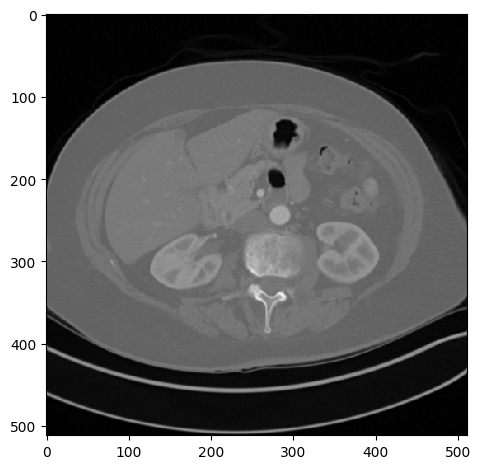

In [1]:
import nibabel as nib
from skimage import io, exposure
import numpy as np

# Load the NIfTI file
# nii_file = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00000/instances/tumor_instance-1_annotation-1.nii.gz'
# nii_file = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00095/segmentation.nii.gz'
nii_file = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00423/imaging.nii.gz'
#
img = nib.load(nii_file)

# Extract image data
img_data = img.get_fdata()
print(img_data.shape)
print(img_data.min(), img_data.max())

# Select a slice to visualize (e.g., the middle slice)
# slice_index = img_data.shape[2] // 2
#
# slice_index
for i in range(img_data.shape[0]):
    if img_data[i, :, :].max() > 1:
        slice_index = i
        break
# slice_index += 30
slice_index = 26
print(slice_index)
slice_data = img_data[slice_index, :, :]
print(slice_data.min(), slice_data.max())

# Normalize the slice data to the range [0, 255]
slice_data = exposure.rescale_intensity(slice_data, out_range=(0, 255))
slice_data = slice_data.astype(np.uint8)
print(slice_data.min(), slice_data.max())
# Show the image using scikit-image
io.imshow(slice_data, cmap='gray')
io.show()

In [1]:
import os
import random

# Create a list of numbers from 0 to 488
number_list = list(range(489))

# Set the random seed for reproducibility
random.seed(20)

# Shuffle the list
random.shuffle(number_list)

# Calculate the split index
split_index = int(0.8 * len(number_list))
print(split_index)
# Split the list into 80% and 20%.
train_list = number_list[:split_index]
test_list = number_list[split_index:]

# Specify the directory and filenames
file_dir = "/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/data/kits"
train_filename = os.path.join(file_dir, 'train.txt')
test_filename = os.path.join(file_dir, 'test.txt')

# Write the train list to train.txt
with open(train_filename, 'w') as train_file:
    for number in train_list:
        train_file.write(f"case_{number:05d}\n")

# Write the test list to test.txt
with open(test_filename, 'w') as test_file:
    for number in test_list:
        test_file.write(f"case_{number:05d}\n")

print(f'Train list has been written to {train_filename}')
print(f'Test list has been written to {test_filename}')

Train list has been written to /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/data/kits/train.txt
Test list has been written to /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/data/kits/test.txt


shape: (163, 512, 512)
img min: 0, img max: 0


Text(0.5, 1.0, 'Imaging')

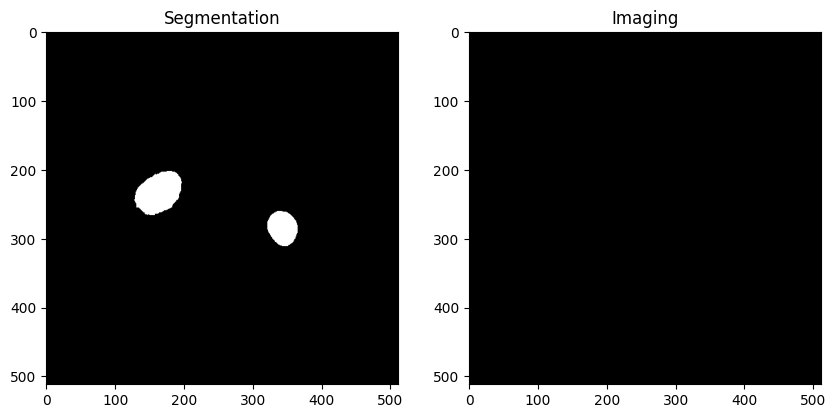

In [11]:
seg_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00526/segmentation.nii.npy'
img_path = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00526/imaging.nii.npy'
seg_scan = np.load(seg_path, mmap_mode='r')
img_scan = np.load(img_path, mmap_mode='r')
assert seg_scan.shape == img_scan.shape
print(f'shape: {seg_scan.shape}')
print(f'img min: {img_scan.min()}, img max: {img_scan.max()}')
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(seg_scan[seg_scan.shape[0] // 2], cmap='gray')
ax[0].set_title('Segmentation')
ax[1].imshow(img_scan[img_scan.shape[0] // 2], cmap='gray')
ax[1].set_title('Imaging')

In [18]:
# Check downloaded imaging raw data
import os
import nibabel as nib
from tqdm import tqdm

# Define the base directory containing the case_xxxxx directories
base_dir = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset'

# List to store the names of directories with errors
error_cases = []

# Iterate through each case_xxxxx directory
for case_dir in tqdm(os.listdir(base_dir)):
    case_path = os.path.join(base_dir, case_dir)
    nii_file = os.path.join(case_path, 'imaging.nii.gz')

    # Check if the nii_file exists
    if os.path.isfile(nii_file):
        try:
            # Load the NIfTI file
            img = nib.load(nii_file)

            # Attempt to extract image data
            img_data = img.get_fdata()
        except Exception as e:
            # If an error occurs, add the case directory to the error list
            error_cases.append(case_dir)
            print(f"Error in {case_dir}: {e}")

# Print the names of directories with errors
print("Directories with errors:")
for case in error_cases:
    print(case)

 10%|█         | 50/490 [01:24<17:27,  2.38s/it]

Error in case_00049: Compressed file ended before the end-of-stream marker was reached


 11%|█         | 54/490 [01:34<20:41,  2.85s/it]

Error in case_00053: Compressed file ended before the end-of-stream marker was reached


 15%|█▍        | 73/490 [02:08<15:52,  2.28s/it]

...

Error in case_00578: Compressed file ended before the end-of-stream marker was reached


 99%|█████████▉| 485/490 [12:05<00:05,  1.11s/it]

Error in case_00584: Compressed file ended before the end-of-stream marker was reached


100%|██████████| 490/490 [12:09<00:00,  1.49s/it]

Directories with errors:
case_00049
case_00053
case_00072
case_00081
case_00095
case_00098
case_00116
case_00120
case_00131
case_00135
case_00146
case_00151
case_00156
case_00159
case_00197
case_00205
case_00213
case_00215
case_00225
case_00227
case_00229
case_00240
case_00244
case_00245
case_00251
case_00266
case_00270
case_00281
case_00288
case_00412
case_00414
case_00419
case_00434
case_00438
case_00456
case_00461
case_00465
case_00485
case_00488
case_00500
case_00512
case_00522
case_00530
case_00540
case_00543
case_00560
case_00561
case_00563
case_00573
case_00574
case_00578
case_00584


In [19]:
print(error_cases)

['case_00049', 'case_00053', 'case_00072', 'case_00081', 'case_00095', 'case_00098', 'case_00116', 'case_00120', 'case_00131', 'case_00135', 'case_00146', 'case_00151', 'case_00156', 'case_00159', 'case_00197', 'case_00205', 'case_00213', 'case_00215', 'case_00225', 'case_00227', 'case_00229', 'case_00240', 'case_00244', 'case_00245', 'case_00251', 'case_00266', 'case_00270', 'case_00281', 'case_00288', 'case_00412', 'case_00414', 'case_00419', 'case_00434', 'case_00438', 'case_00456', 'case_00461', 'case_00465', 'case_00485', 'case_00488', 'case_00500', 'case_00512', 'case_00522', 'case_00530', 'case_00540', 'case_00543', 'case_00560', 'case_00561', 'case_00563', 'case_00573', 'case_00574', 'case_00578', 'case_00584']


In [20]:
# Iterate through each directory in error_cases
for case in error_cases:
    case_path = os.path.join(base_dir, case)

    # Iterate through all files in the directory
    for file_name in os.listdir(case_path):
        if 'imaging' in file_name:
            file_path = os.path.join(case_path, file_name)

            # Check if the file exists
            if os.path.isfile(file_path):
                try:
                    # Delete the file
                    os.remove(file_path)
                    print(f"Deleted {file_path}")
                except Exception as e:
                    print(f"Error deleting {file_path}: {e}")

Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00049/imaging.nii.gz
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00049/imaging_test.nii.npy
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00053/imaging.nii.gz
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00053/imaging.nii.npy
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00053/imaging.nii_kidney_thresh_100.npy
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00053/imaging.nii_tumor_thresh_1000.npy
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00072/imaging.nii.gz
Deleted /media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset/case_00072/imaging.nii.npy
De

In [11]:
# check the segmentation data labels
# Check downloaded imaging raw data
import os
import nibabel as nib
from tqdm import tqdm
import numpy as np


# Define the base directory containing the case_xxxxx directories
base_dir = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset'

# List to store the names of directories with errors
error_cases = []
num_bg = 0
num_kidney = 0
num_tumor = 0
num_cyst = 0
# Iterate through each case_xxxxx directory
case_dirs = [d for d in os.listdir(base_dir) if 'case' in d]
for case_dir in tqdm(case_dirs):
    case_path = os.path.join(base_dir, case_dir)
    nii_file = os.path.join(case_path, 'segmentation.nii.gz')

    try:
        # Load the NIfTI file
        img = nib.load(nii_file)
        # Attempt to extract image data
        img_data = img.get_fdata().astype(np.uint8)
        for slice_index in range(img_data.shape[0]):
            slice_data = img_data[slice_index, :, :]
            if np.sum(slice_data == 0) > 1:
                num_bg += 1
            if np.sum(slice_data == 1) > 1:
                num_kidney += 1
            if np.sum(slice_data == 2) > 1:
                num_tumor += 1
            if np.sum(slice_data == 3) > 1:
                num_cyst += 1

        # break

    except Exception as e:
        # If an error occurs, add the case directory to the error list
        error_cases.append(case_dir)
        print(f"Error in {case_dir}: {e}")

# Print the names of directories with errors
print("Directories with errors:")
for case in error_cases:
    print(case)
print(f'total slices: {num_bg}, num_kidney: {num_kidney}, num_tumor: {num_tumor}, num_cyst: {num_cyst}')

100%|██████████| 489/489 [10:12<00:00,  1.25s/it]

Directories with errors:
total slices: 95221, num_kidney: 32358, num_tumor: 12173, num_cyst: 4671


In [ ]:
import os
import torch.multiprocessing as mp
from tqdm import tqdm
import nibabel as nib
import numpy as np

base_dir = '/media/NAS06/gavinyue/disentanglement/benchmark/counterfactual-search/kits23/dataset'

# List to store the names of directories with errors
error_cases = mp.Manager().list()
num_bg = mp.Value('i', 0)
num_kidney = mp.Value('i', 0)
num_tumor = mp.Value('i', 0)
num_cyst = mp.Value('i', 0)


# Function to process each case directory
def process_case(case_dir, error_cases, num_bg, num_kidney, num_tumor, num_cyst):
    case_path = os.path.join(base_dir, case_dir)
    nii_file = os.path.join(case_path, 'segmentation.nii.gz')

    local_num_bg = 0
    local_num_kidney = 0
    local_num_tumor = 0
    local_num_cyst = 0

    try:
        # Load the NIfTI file
        img = nib.load(nii_file)
        # Attempt to extract image data
        img_data = img.get_fdata().astype(np.uint8)
        for slice_index in range(img_data.shape[0]):
            slice_data = img_data[slice_index, :, :]
            if np.sum(slice_data == 0) > 1:
                local_num_bg += 1
            if np.sum(slice_data == 1) > 1:
                local_num_kidney += 1
            if np.sum(slice_data == 2) > 1:
                local_num_tumor += 1
            if np.sum(slice_data == 3) > 1:
                local_num_cyst += 1
    except Exception as e:
        # If an error occurs, add the case directory to the error list
        error_cases.append(case_dir)
        print(f"Error in {case_dir}: {e}")
        return

    with num_bg.get_lock():
        num_bg.value += local_num_bg
    with num_kidney.get_lock():
        num_kidney.value += local_num_kidney
    with num_tumor.get_lock():
        num_tumor.value += local_num_tumor
    with num_cyst.get_lock():
        num_cyst.value += local_num_cyst


# Iterate through each case_xxxxx directory
case_dirs = [d for d in os.listdir(base_dir) if 'case' in d]

# Use torch.multiprocessing.Pool to parallelize the processing
with mp.Pool() as pool:
    for _ in tqdm(
        pool.imap_unordered(process_case, [(case_dir, error_cases, num_bg, num_kidney, num_tumor, num_cyst) for case_dir in case_dirs]), total=len(case_dirs)
    ):
        pass

# Print the names of directories with errors
print("Directories with errors:")
for case in error_cases:
    print(case)
print(f'total slices: {num_bg.value}, num_kidney: {num_kidney.value}, num_tumor: {num_tumor.value}, num_cyst: {num_cyst.value}')